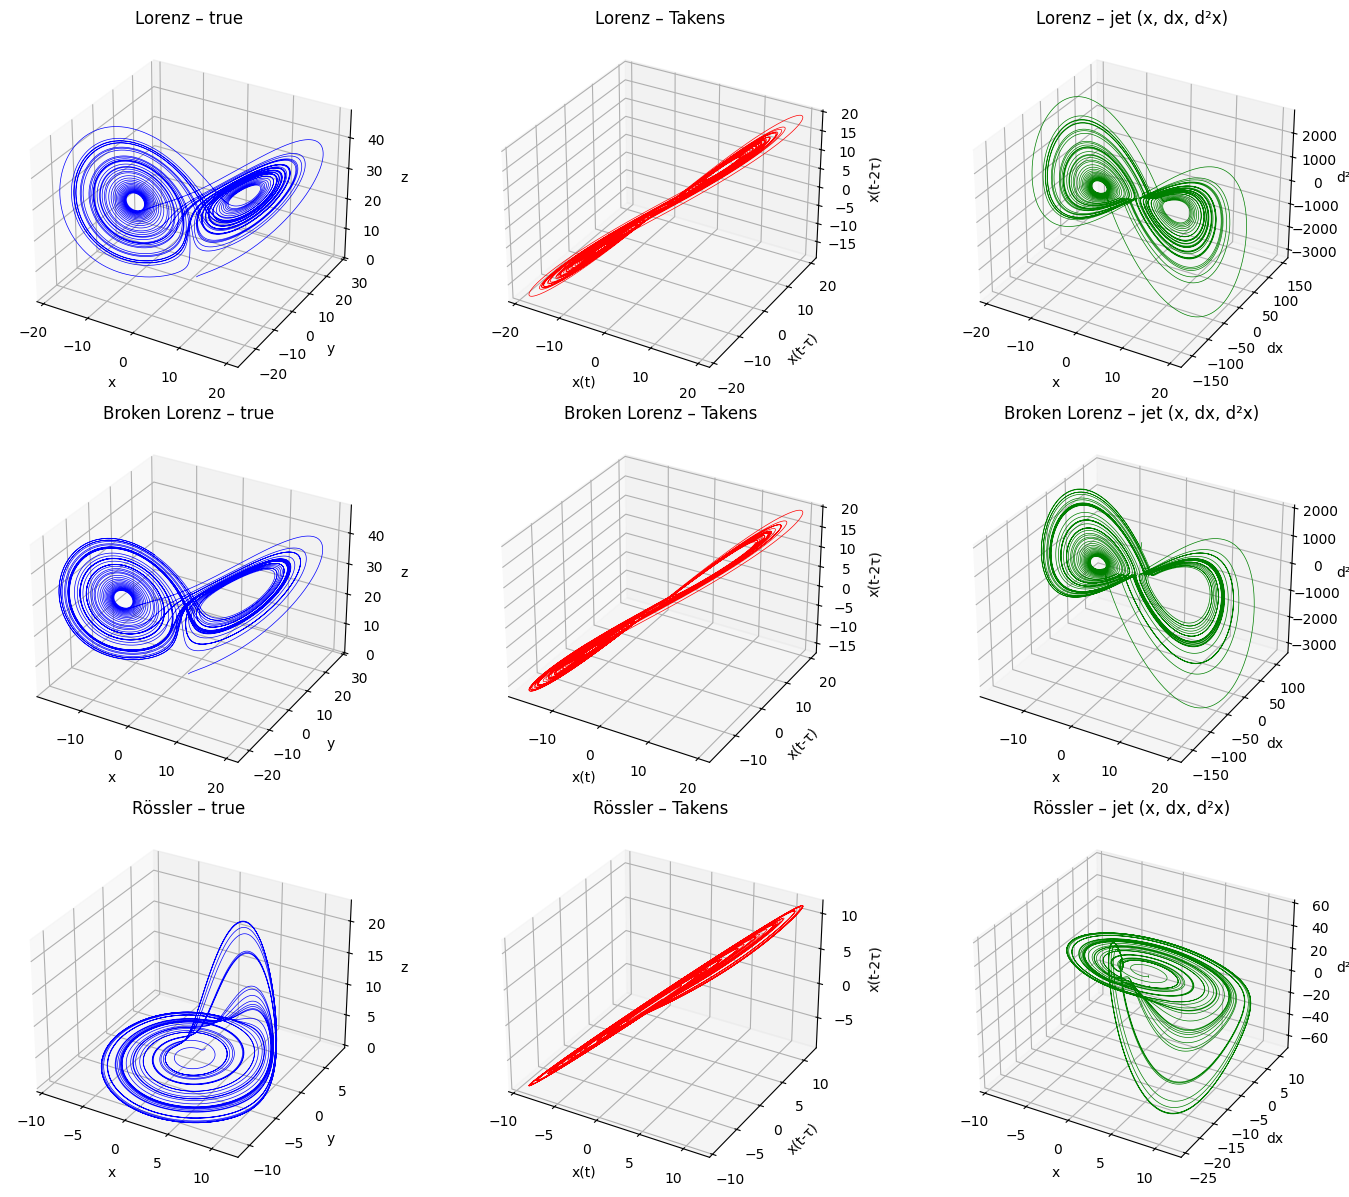

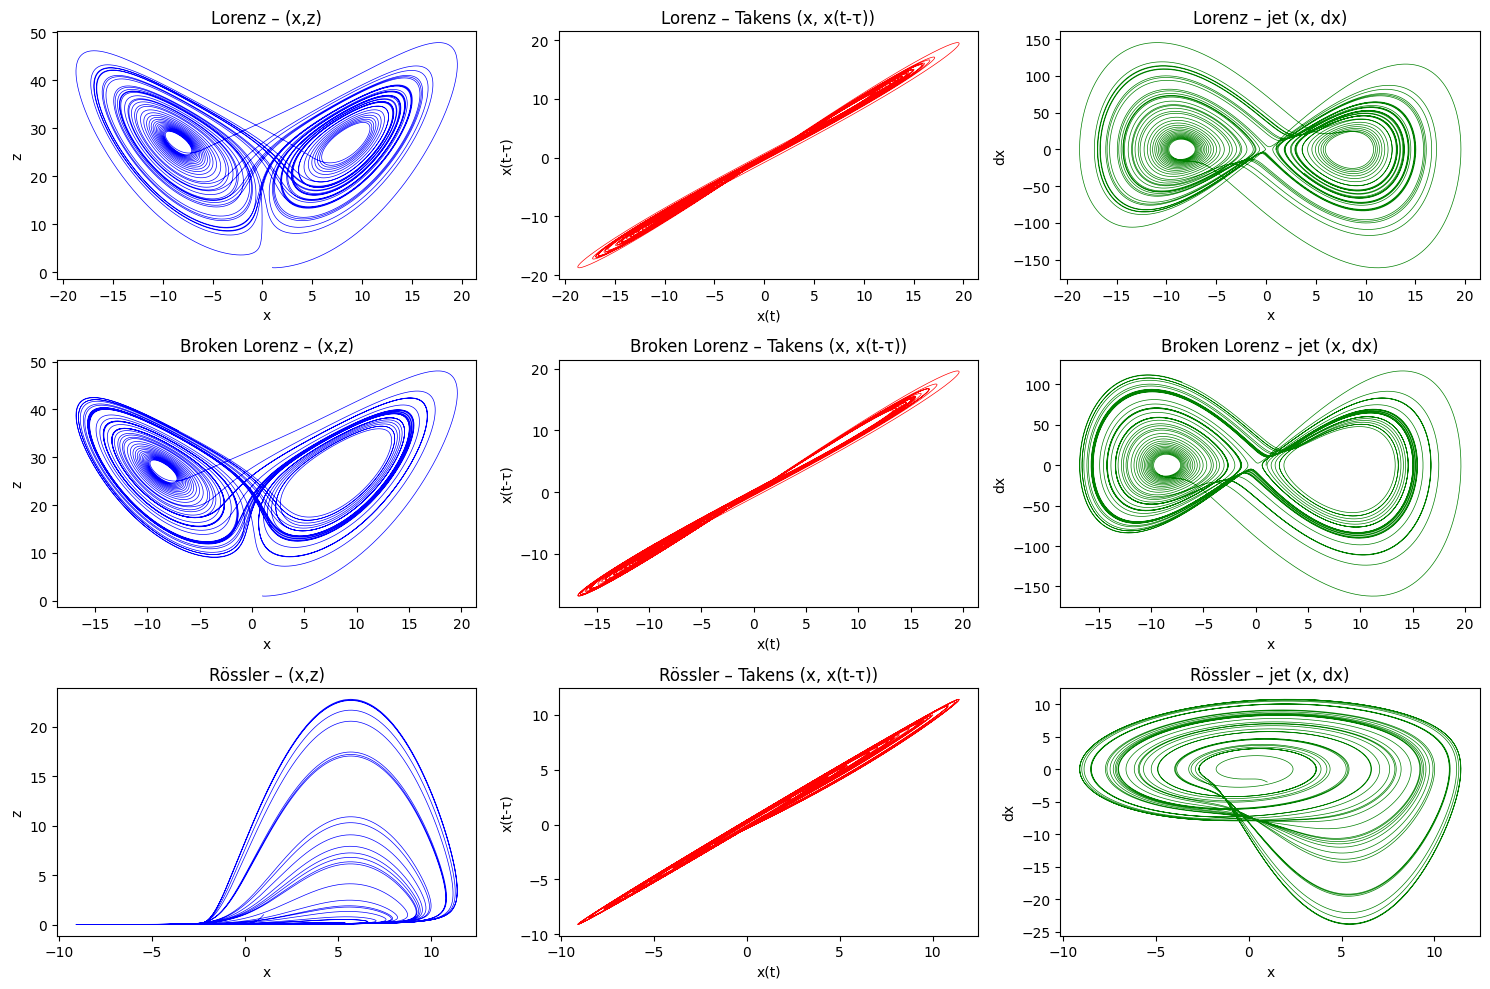

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. System definitions and helper functions
# ------------------------------------------------------------
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y-x), x*(rho-z)-y, x*y - beta*z]

def lorenz_broken(t, state, sigma=10, rho=28, beta=8/3, eps=0.1):
    x, y, z = state
    return [sigma*(y-x), x*(rho-z)-y + eps*x, x*y - beta*z]

def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    return [-y - z, x + a*y, b + z*(x - c)]

def generate_series(system, t_span, t_eval, y0, **kwargs):
    sol = solve_ivp(lambda t, y: system(t, y, **kwargs), t_span, y0,
                    t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T

def central_deriv(s, dt):
    ds = np.zeros_like(s)
    ds[1:-1] = (s[2:] - s[:-2]) / (2*dt)
    ds[0] = (s[1] - s[0]) / dt
    ds[-1] = (s[-1] - s[-2]) / dt
    return ds

def jet_embedding(s, dt, order=2):
    # order=2 gives (x, dx, d2x)
    d1 = central_deriv(s, dt)
    d2 = central_deriv(d1, dt)
    return np.column_stack((s, d1, d2))

def takens_embedding(s, delay=10, dim=3):
    N = len(s)
    idx = np.arange(N - (dim-1)*delay)
    emb = np.zeros((len(idx), dim))
    for i in range(dim):
        emb[:, i] = s[idx + i*delay]
    return emb

# ------------------------------------------------------------
# 2. Generate data for all systems
# ------------------------------------------------------------
# Lorenz
tL = np.linspace(0, 50, 50000)
_, lorenz_data = generate_series(lorenz, (0,50), tL, [1.0,1.0,1.0])
xL, yL, zL = lorenz_data[:,0], lorenz_data[:,1], lorenz_data[:,2]
dtL = tL[1] - tL[0]
jetL = jet_embedding(xL, dtL, order=2)
takensL = takens_embedding(xL, delay=10, dim=3)

# Broken Lorenz
_, lb_data = generate_series(lorenz_broken, (0,50), tL, [1.0,1.0,1.0], eps=0.1)
xLB, yLB, zLB = lb_data[:,0], lb_data[:,1], lb_data[:,2]
jetLB = jet_embedding(xLB, dtL, order=2)
takensLB = takens_embedding(xLB, delay=10, dim=3)

# Rössler
tR = np.linspace(0, 200, 50000)
_, rossler_data = generate_series(rossler, (0,200), tR, [1.0,1.0,1.0])
xR, yR, zR = rossler_data[:,0], rossler_data[:,1], rossler_data[:,2]
dtR = tR[1] - tR[0]
jetR = jet_embedding(xR, dtR, order=2)
takensR = takens_embedding(xR, delay=10, dim=3)

# ------------------------------------------------------------
# 3. Figure 1: 3D reconstructions
# ------------------------------------------------------------
fig1 = plt.figure(figsize=(15, 12))

# Row 1: Lorenz (symmetric)
ax1 = fig1.add_subplot(3,3,1, projection='3d')
ax1.plot(xL, yL, zL, linewidth=0.5, color='blue')
ax1.set_title('Lorenz – true')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig1.add_subplot(3,3,2, projection='3d')
ax2.plot(takensL[:,0], takensL[:,1], takensL[:,2], linewidth=0.5, color='red')
ax2.set_title('Lorenz – Takens')
ax2.set_xlabel('x(t)'); ax2.set_ylabel('x(t-τ)'); ax2.set_zlabel('x(t-2τ)')

ax3 = fig1.add_subplot(3,3,3, projection='3d')
ax3.plot(jetL[:,0], jetL[:,1], jetL[:,2], linewidth=0.5, color='green')
ax3.set_title('Lorenz – jet (x, dx, d²x)')
ax3.set_xlabel('x'); ax3.set_ylabel('dx'); ax3.set_zlabel('d²x')

# Row 2: Broken Lorenz
ax4 = fig1.add_subplot(3,3,4, projection='3d')
ax4.plot(xLB, yLB, zLB, linewidth=0.5, color='blue')
ax4.set_title('Broken Lorenz – true')
ax4.set_xlabel('x'); ax4.set_ylabel('y'); ax4.set_zlabel('z')

ax5 = fig1.add_subplot(3,3,5, projection='3d')
ax5.plot(takensLB[:,0], takensLB[:,1], takensLB[:,2], linewidth=0.5, color='red')
ax5.set_title('Broken Lorenz – Takens')
ax5.set_xlabel('x(t)'); ax5.set_ylabel('x(t-τ)'); ax5.set_zlabel('x(t-2τ)')

ax6 = fig1.add_subplot(3,3,6, projection='3d')
ax6.plot(jetLB[:,0], jetLB[:,1], jetLB[:,2], linewidth=0.5, color='green')
ax6.set_title('Broken Lorenz – jet (x, dx, d²x)')
ax6.set_xlabel('x'); ax6.set_ylabel('dx'); ax6.set_zlabel('d²x')

# Row 3: Rössler
ax7 = fig1.add_subplot(3,3,7, projection='3d')
ax7.plot(xR, yR, zR, linewidth=0.5, color='blue')
ax7.set_title('Rössler – true')
ax7.set_xlabel('x'); ax7.set_ylabel('y'); ax7.set_zlabel('z')

ax8 = fig1.add_subplot(3,3,8, projection='3d')
ax8.plot(takensR[:,0], takensR[:,1], takensR[:,2], linewidth=0.5, color='red')
ax8.set_title('Rössler – Takens')
ax8.set_xlabel('x(t)'); ax8.set_ylabel('x(t-τ)'); ax8.set_zlabel('x(t-2τ)')

ax9 = fig1.add_subplot(3,3,9, projection='3d')
ax9.plot(jetR[:,0], jetR[:,1], jetR[:,2], linewidth=0.5, color='green')
ax9.set_title('Rössler – jet (x, dx, d²x)')
ax9.set_xlabel('x'); ax9.set_ylabel('dx'); ax9.set_zlabel('d²x')

plt.tight_layout()
plt.savefig('3d_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 4. Figure 2: 2D phase portraits
# ------------------------------------------------------------
fig2 = plt.figure(figsize=(15, 10))

# Lorenz
ax1 = fig2.add_subplot(3,3,1)
ax1.plot(xL, zL, linewidth=0.5, color='blue')
ax1.set_title('Lorenz – (x,z)')
ax1.set_xlabel('x'); ax1.set_ylabel('z')

ax2 = fig2.add_subplot(3,3,2)
ax2.plot(takensL[:,0], takensL[:,1], linewidth=0.5, color='red')
ax2.set_title('Lorenz – Takens (x, x(t-τ))')
ax2.set_xlabel('x(t)'); ax2.set_ylabel('x(t-τ)')

ax3 = fig2.add_subplot(3,3,3)
ax3.plot(jetL[:,0], jetL[:,1], linewidth=0.5, color='green')
ax3.set_title('Lorenz – jet (x, dx)')
ax3.set_xlabel('x'); ax3.set_ylabel('dx')

# Broken Lorenz
ax4 = fig2.add_subplot(3,3,4)
ax4.plot(xLB, zLB, linewidth=0.5, color='blue')
ax4.set_title('Broken Lorenz – (x,z)')
ax4.set_xlabel('x'); ax4.set_ylabel('z')

ax5 = fig2.add_subplot(3,3,5)
ax5.plot(takensLB[:,0], takensLB[:,1], linewidth=0.5, color='red')
ax5.set_title('Broken Lorenz – Takens (x, x(t-τ))')
ax5.set_xlabel('x(t)'); ax5.set_ylabel('x(t-τ)')

ax6 = fig2.add_subplot(3,3,6)
ax6.plot(jetLB[:,0], jetLB[:,1], linewidth=0.5, color='green')
ax6.set_title('Broken Lorenz – jet (x, dx)')
ax6.set_xlabel('x'); ax6.set_ylabel('dx')

# Rössler
ax7 = fig2.add_subplot(3,3,7)
ax7.plot(xR, zR, linewidth=0.5, color='blue')
ax7.set_title('Rössler – (x,z)')
ax7.set_xlabel('x'); ax7.set_ylabel('z')

ax8 = fig2.add_subplot(3,3,8)
ax8.plot(takensR[:,0], takensR[:,1], linewidth=0.5, color='red')
ax8.set_title('Rössler – Takens (x, x(t-τ))')
ax8.set_xlabel('x(t)'); ax8.set_ylabel('x(t-τ)')

ax9 = fig2.add_subplot(3,3,9)
ax9.plot(jetR[:,0], jetR[:,1], linewidth=0.5, color='green')
ax9.set_title('Rössler – jet (x, dx)')
ax9.set_xlabel('x'); ax9.set_ylabel('dx')

plt.tight_layout()
plt.savefig('2d_phase_portraits.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.spatial import KDTree

# ------------------------------------------------------------
# 1. System definitions and data generation
# ------------------------------------------------------------
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y-x), x*(rho-z)-y, x*y - beta*z]

def lorenz_broken(t, state, sigma=10, rho=28, beta=8/3, eps=0.1):
    x, y, z = state
    return [sigma*(y-x), x*(rho-z)-y + eps*x, x*y - beta*z]

def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    return [-y - z, x + a*y, b + z*(x - c)]

def generate_series(system, t_span, t_eval, y0, **kwargs):
    sol = solve_ivp(lambda t, y: system(t, y, **kwargs), t_span, y0,
                    t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T

# ------------------------------------------------------------
# 2. Reconstruction helpers
# ------------------------------------------------------------
def central_deriv(s, dt):
    ds = np.zeros_like(s)
    ds[1:-1] = (s[2:] - s[:-2]) / (2*dt)
    ds[0] = (s[1] - s[0]) / dt
    ds[-1] = (s[-1] - s[-2]) / dt
    return ds

def takens_embedding(s, delay=10, dim=2):
    N = len(s)
    idx = np.arange(N - (dim-1)*delay)
    emb = np.zeros((len(idx), dim))
    for i in range(dim):
        emb[:, i] = s[idx + i*delay]
    return emb

def jet_2d(s, dt):
    return np.column_stack((s, central_deriv(s, dt)))

# ------------------------------------------------------------
# 3. Correlation dimension (Grassberger–Procaccia)
#    Parameters as in Section 3.6.5 of the arXiv paper
# ------------------------------------------------------------
def correlation_dimension(points, sample_frac=0.3, n_eps=20, seed=42):
    np.random.seed(seed)
    n = len(points)
    idx = np.random.choice(n, int(n * sample_frac), replace=False)
    pts = points[idx]
    tree = KDTree(pts)
    eps_min = 0.01 * np.std(pts)
    eps_max = 0.5 * np.std(pts)
    eps = np.logspace(np.log10(eps_min), np.log10(eps_max), n_eps)
    C = np.zeros_like(eps)
    for i, e in enumerate(eps):
        counts = tree.query_ball_point(pts, e, return_length=True)
        C[i] = np.mean(counts) / (len(pts) - 1)
    log_eps = np.log(eps)
    log_C = np.log(C)
    deriv = np.gradient(log_C, log_eps)
    window = 5
    best_start = 0
    best_std = np.inf
    for i in range(len(deriv) - window):
        seg = deriv[i:i+window]
        if np.std(seg) < best_std:
            best_std = np.std(seg)
            best_start = i
    coeffs = np.polyfit(log_eps[best_start:best_start+window],
                        log_C[best_start:best_start+window], 1)
    return coeffs[0]

# ------------------------------------------------------------
# 4. Generate data and reconstructions
# ------------------------------------------------------------
# Parameters from the paper
tL = np.linspace(0, 100, 100000)   # Lorenz: 100 sec, dt = 0.001
tR = np.linspace(0, 500, 100000)   # Rössler: 500 sec, dt = 0.005

# Lorenz (symmetric)
_, dataL = generate_series(lorenz, (0,100), tL, [1.0,1.0,1.0])
xL, yL, zL = dataL[:,0], dataL[:,1], dataL[:,2]
dtL = tL[1] - tL[0]

# Lorenz (broken symmetry)
_, dataLB = generate_series(lorenz_broken, (0,100), tL, [1.0,1.0,1.0], eps=0.1)
xLB, yLB, zLB = dataLB[:,0], dataLB[:,1], dataLB[:,2]

# Rössler
_, dataR = generate_series(rossler, (0,500), tR, [1.0,1.0,1.0])
xR, yR, zR = dataR[:,0], dataR[:,1], dataR[:,2]
dtR = tR[1] - tR[0]

# Reference projections (x, z)
ref_L = np.column_stack((xL, zL))
ref_LB = np.column_stack((xLB, zLB))
ref_R = np.column_stack((xR, zR))

# Takens 2D
tak_L = takens_embedding(xL, delay=10, dim=2)
tak_LB = takens_embedding(xLB, delay=10, dim=2)
tak_R = takens_embedding(xR, delay=10, dim=2)

# Jet 2D (x, dx)
jet_L = jet_2d(xL, dtL)
jet_LB = jet_2d(xLB, dtL)
jet_R = jet_2d(xR, dtR)

# ------------------------------------------------------------
# 5. Compute correlation dimensions and print Table 2
# ------------------------------------------------------------
print("Table: Correlation dimension estimates")
print("System          Theoretical  Reference  Takens  Jet-space")
print("----------------------------------------------------------")

systems = [
    ("Lorenz (sym.)", ref_L, tak_L, jet_L, 2.06),
    ("Lorenz (broken)", ref_LB, tak_LB, jet_LB, 2.06),
    ("Rössler", ref_R, tak_R, jet_R, 2.0)
]

for name, ref, tak, jet, theo in systems:
    d_ref = correlation_dimension(ref)
    d_tak = correlation_dimension(tak)
    d_jet = correlation_dimension(jet)
    print(f"{name:16s} {theo:6.2f}   {d_ref:8.3f}  {d_tak:8.3f}  {d_jet:8.3f}")

Table: Correlation dimension estimates
System          Theoretical  Reference  Takens  Jet-space
----------------------------------------------------------
Lorenz (sym.)      2.06      1.925     1.634     1.693
Lorenz (broken)    2.06      1.899     1.662     1.741
Rössler            2.00      1.063     1.750     1.856


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter
from scipy.spatial import KDTree

# ------------------------------------------------------------
# 1. Generate Rössler signal
# ------------------------------------------------------------
def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    return [-y - z, x + a*y, b + z*(x - c)]

t_span = (0, 500)
num_points = 10000
t_eval = np.linspace(0, 500, num_points)
sol = solve_ivp(rossler, t_span, [1.0, 1.0, 1.0], t_eval=t_eval,
                method='RK45', rtol=1e-10, atol=1e-12)
x = sol.y[0]
dt = t_eval[1] - t_eval[0]

# ------------------------------------------------------------
# 2. Reconstruction functions
# ------------------------------------------------------------
def deriv_central(s, dt):
    ds = np.zeros_like(s)
    ds[1:-1] = (s[2:] - s[:-2]) / (2 * dt)
    ds[0] = (s[1] - s[0]) / dt
    ds[-1] = (s[-1] - s[-2]) / dt
    return ds

def jet_embedding(s, dt, method='central', window=21, order=3):
    if method == 'central':
        d1 = deriv_central(s, dt)
        d2 = deriv_central(d1, dt)
        return np.column_stack((s, d1, d2))
    elif method == 'savitzky':
        s_f = savgol_filter(s, window, order)
        d1 = savgol_filter(s, window, order, deriv=1, delta=dt)
        d2 = savgol_filter(s, window, order, deriv=2, delta=dt)
        return np.column_stack((s_f, d1, d2))
    else:
        raise ValueError("Unknown method")

# ------------------------------------------------------------
# 3. Original and shifted signals
# ------------------------------------------------------------
shift = 10   # shift by 10 samples
x_shift = x[shift:]          # truncated signal

# Jet reconstruction of the original signal
jet_cent = jet_embedding(x, dt, 'central')
jet_sg   = jet_embedding(x, dt, 'savitzky')
# Shift in jet space (S_tau J[x])
jet_cent_shifted = jet_cent[shift:]
jet_sg_shifted   = jet_sg[shift:]

# Reconstruction of the shifted signal (J[S_tau x])
jet_cent_from_shift = jet_embedding(x_shift, dt, 'central')
jet_sg_from_shift   = jet_embedding(x_shift, dt, 'savitzky')

# ------------------------------------------------------------
# 4. Compare Hausdorff distances
# ------------------------------------------------------------
def hausdorff(A, B):
    treeA = KDTree(A)
    treeB = KDTree(B)
    dA = np.max(treeA.query(B)[0])
    dB = np.max(treeB.query(A)[0])
    return max(dA, dB)

dist_cent = hausdorff(jet_cent_shifted, jet_cent_from_shift)
dist_sg   = hausdorff(jet_sg_shifted, jet_sg_from_shift)

print(f"Hausdorff distance (central differences): {dist_cent:.6e}")
print(f"Hausdorff distance (Savitzky–Golay filter): {dist_sg:.6e}")

Hausdorff distance (central differences): 1.147204e-02
Hausdorff distance (Savitzky–Golay filter): 4.228773e-01


Hausdorff distance (central differences): 3.554019e+01
Hausdorff distance (Savitzky–Golay filter): 3.991901e+01


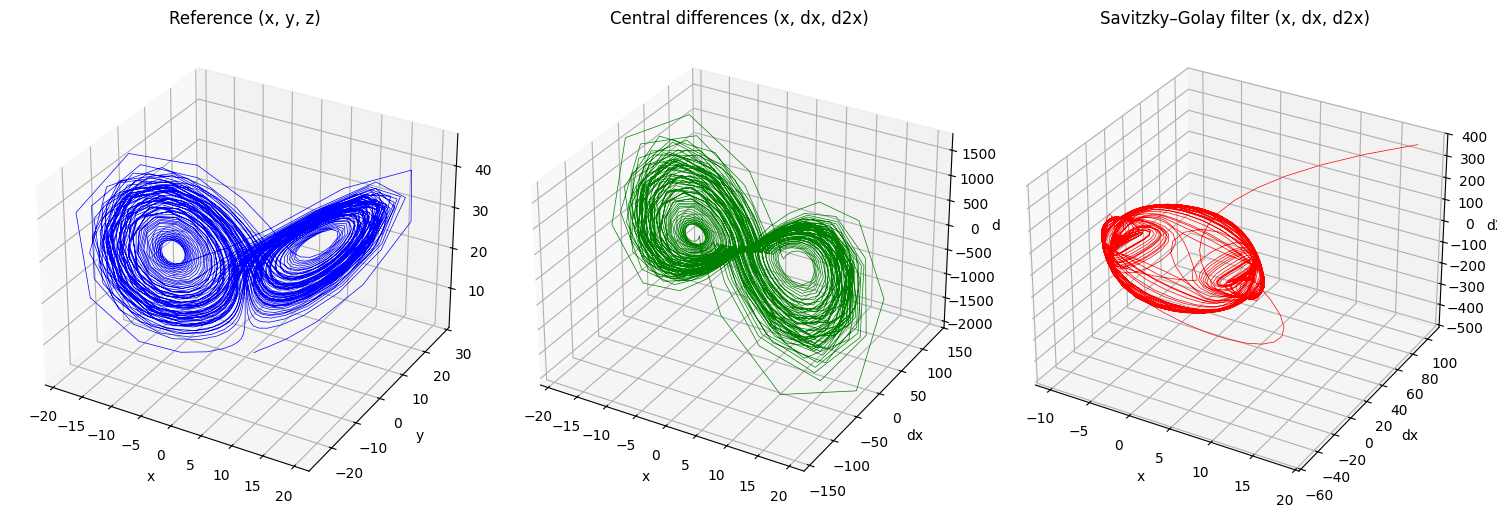

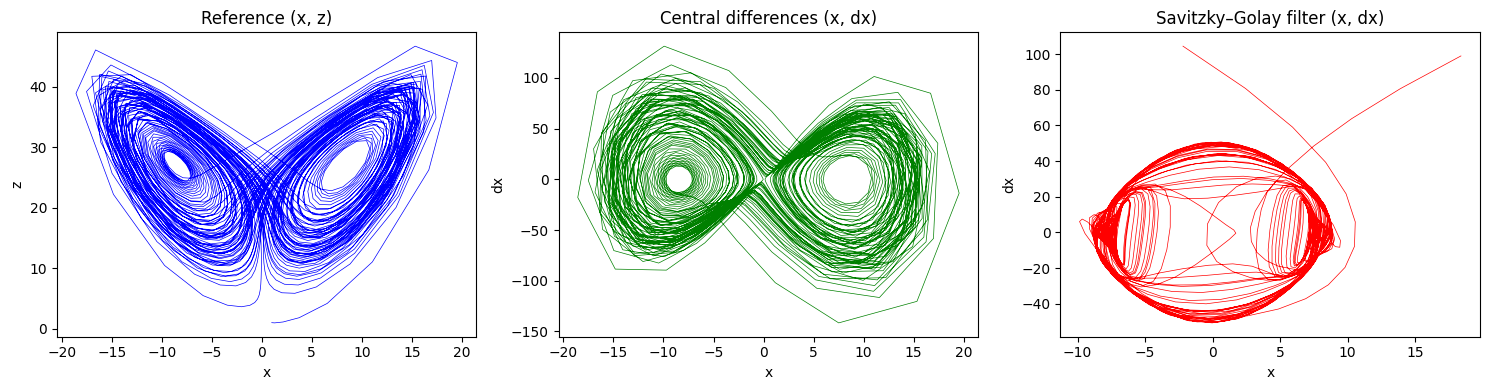

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter
from scipy.spatial import KDTree
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. Generate Lorenz time series (very coarse sampling)
# ------------------------------------------------------------
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y-x), x*(rho-z)-y, x*y - beta*z]

t_span = (0, 100)
num_points = 2000                    # very coarse sampling (step 0.05)
t_eval = np.linspace(0, 100, num_points)
y0 = [1.0, 1.0, 1.0]

sol = solve_ivp(lorenz, t_span, y0, t_eval=t_eval, method='RK45',
                rtol=1e-10, atol=1e-12)
t = sol.t
x, y, z = sol.y
signal = x
dt = t[1] - t[0]

# ------------------------------------------------------------
# 2. Reconstruction functions
# ------------------------------------------------------------
def deriv_central(s, dt):
    ds = np.zeros_like(s)
    ds[1:-1] = (s[2:] - s[:-2]) / (2*dt)
    ds[0] = (s[1] - s[0]) / dt
    ds[-1] = (s[-1] - s[-2]) / dt
    return ds

def jet_embedding(s, dt, method='central', window=25, order=3):
    if method == 'central':
        d1 = deriv_central(s, dt)
        d2 = deriv_central(d1, dt)
        return np.column_stack((s, d1, d2))
    elif method == 'savitzky':
        # With coarse sampling, increase window to make smoothing more pronounced
        s_f = savgol_filter(s, window, order)
        d1 = savgol_filter(s, window, order, deriv=1, delta=dt)
        d2 = savgol_filter(s, window, order, deriv=2, delta=dt)
        return np.column_stack((s_f, d1, d2))
    else:
        raise ValueError("Unknown method")

# ------------------------------------------------------------
# 3. Test commutation with time shift
# ------------------------------------------------------------
shift = 10   # shift by 10 samples
x_shift = x[shift:]   # shifted signal (truncated)

# Reconstruction of original signal
jet_cent = jet_embedding(x, dt, 'central')
jet_sg   = jet_embedding(x, dt, 'savitzky', window=25)

# Shift in jet space (S_tau J[x])
jet_cent_shifted = jet_cent[shift:]
jet_sg_shifted   = jet_sg[shift:]

# Reconstruction of shifted signal (J[S_tau x])
jet_cent_from_shift = jet_embedding(x_shift, dt, 'central')
jet_sg_from_shift   = jet_embedding(x_shift, dt, 'savitzky', window=25)

# Hausdorff distance between two sets in the same jet space
def hausdorff(A, B):
    treeA = KDTree(A)
    treeB = KDTree(B)
    dA = np.max(treeA.query(B)[0])
    dB = np.max(treeB.query(A)[0])
    return max(dA, dB)

dist_cent = hausdorff(jet_cent_shifted, jet_cent_from_shift)
dist_sg   = hausdorff(jet_sg_shifted, jet_sg_from_shift)

print(f"Hausdorff distance (central differences): {dist_cent:.6e}")
print(f"Hausdorff distance (Savitzky–Golay filter): {dist_sg:.6e}")

# ------------------------------------------------------------
# 4. Visualisation of 3D attractors
# ------------------------------------------------------------
# Show reference (x, y, z), central differences, and filter in their own coordinates
fig = plt.figure(figsize=(15, 5))

# Reference (x, y, z)
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(x, y, z, linewidth=0.5, color='blue')
ax1.set_title('Reference (x, y, z)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# Jet space (central differences)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(jet_cent[:,0], jet_cent[:,1], jet_cent[:,2],
         linewidth=0.5, color='green')
ax2.set_title('Central differences (x, dx, d2x)')
ax2.set_xlabel('x'); ax2.set_ylabel('dx'); ax2.set_zlabel('d2x')

# Jet space (Savitzky–Golay filter)
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(jet_sg[:,0], jet_sg[:,1], jet_sg[:,2],
         linewidth=0.5, color='red')
ax3.set_title('Savitzky–Golay filter (x, dx, d2x)')
ax3.set_xlabel('x'); ax3.set_ylabel('dx'); ax3.set_zlabel('d2x')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Additional: projection onto (x, dx) for clarity
# ------------------------------------------------------------
fig2, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, z, linewidth=0.5, color='blue')
axes[0].set_title('Reference (x, z)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('z')

axes[1].plot(jet_cent[:,0], jet_cent[:,1], linewidth=0.5, color='green')
axes[1].set_title('Central differences (x, dx)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('dx')

axes[2].plot(jet_sg[:,0], jet_sg[:,1], linewidth=0.5, color='red')
axes[2].set_title('Savitzky–Golay filter (x, dx)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('dx')

plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# DATA GENERATION FOR THE ARTICLE (Colab cell)
# ================================================================
# Run this cell once to create the CSV files:
#   eigen_coords.csv, original_vs_fit.csv, model_params.txt
# ================================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.linalg import eigvals, eig
from scipy.optimize import minimize

# ================================================================
# 1. GENERATE THE RÖSSLER SYSTEM
# ================================================================
def roessler(t, state, a, b, c):
    x, y, z = state
    return [-y - z, x + a*y, b + z*(x - c)]

a, b = 0.2, 0.2
c = 5.7
x0 = [0.1, 0.0, 0.1]
t_span = (0, 200)
t_eval = np.linspace(0, 200, 20000)
dt = t_eval[1] - t_eval[0]

sol = solve_ivp(roessler, t_span, x0, args=(a,b,c),
                t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
x_orig, y_orig, z_orig = sol.y
print("✅ Original time series generated")

# ================================================================
# 2. JET SPACE (CENTRAL DIFFERENCES)
# ================================================================
def get_jet(signal, dt, order=2):
    derivs = [signal]
    cur = signal
    for _ in range(order):
        cur = np.gradient(cur, dt)
        derivs.append(cur)
    return np.column_stack(derivs)

jet = get_jet(x_orig, dt, order=2)

# ================================================================
# 3. FIND A SADDLE-FOCUS (LOCAL LINEARIZATION)
# ================================================================
norm = np.linalg.norm(jet, axis=1)
peaks, _ = find_peaks(-norm, distance=50)
window_half = 15
best_candidate = None
best_ratio = -np.inf
best_lam = best_sigma = best_omega = None
best_J = None

for idx in peaks:
    if idx < window_half or idx > len(jet) - window_half - 1:
        continue
    R = jet[idx - window_half : idx + window_half + 1, :]
    Rdot = np.gradient(R, dt, axis=0)
    J = np.linalg.lstsq(R, Rdot, rcond=None)[0]
    ev = eigvals(J)
    real_evs = [e for e in ev if np.abs(e.imag) < 1e-6]
    compl_evs = [e for e in ev if np.abs(e.imag) > 1e-6]
    if len(real_evs) == 1 and len(compl_evs) == 2:
        lam = real_evs[0].real
        sigma = compl_evs[0].real
        omega = np.abs(compl_evs[0].imag)
        if lam > 0 and sigma < 0:
            ratio = lam / abs(sigma)
            if ratio > best_ratio:
                best_ratio = ratio
                best_candidate = idx
                best_lam, best_sigma, best_omega = lam, sigma, omega
                best_J = J

print(f"Saddle-focus: λ={best_lam:.4f}, σ={best_sigma:.4f}, ω={best_omega:.4f}, λ/|σ|={best_ratio:.4f}")

# ================================================================
# 4. PROJECTION INTO EIGENCOORDINATES
# ================================================================
evals, evecs = eig(best_J)
real_idx = None
compl_idx = None
for i, ev in enumerate(evals):
    if np.abs(ev.imag) < 1e-6:
        real_idx = i
    else:
        compl_idx = i

if real_idx is None or compl_idx is None:
    raise RuntimeError("Failed to identify eigenvector indices")

T_inv = np.linalg.inv(evecs)
win_size = 60
idx_start = max(0, best_candidate - win_size)
idx_end = min(len(jet), best_candidate + win_size)
t_local = t_eval[idx_start:idx_end]
R_local = jet[idx_start:idx_end, :]
R_proj = (T_inv @ R_local.T).T
u_real = R_proj[:, real_idx].real
u1 = R_proj[:, compl_idx].real
u2 = R_proj[:, compl_idx].imag

# ================================================================
# 5. FIT THE MODEL (NONLINEAR ADD-ON)
# ================================================================
def model_plane(t, A, phi, C):
    return A * np.exp(best_sigma * t) * np.sin(best_omega * t + phi) + C

def error_plane(params, t, data1, data2):
    A, phi, C = params
    pred1 = model_plane(t, A, phi, C)
    pred2 = model_plane(t, A, phi + np.pi/2, C)
    return np.sum((data1 - pred1)**2 + (data2 - pred2)**2)

res = minimize(error_plane, [np.std(u1), 0.0, np.mean(u1)], args=(t_local, u1, u2), method='Nelder-Mead')
A_opt, phi_opt, C_opt = res.x
u1_fit = model_plane(t_local, A_opt, phi_opt, C_opt)
u2_fit = model_plane(t_local, A_opt, phi_opt + np.pi/2, C_opt)

def model_unstable(t, B, D):
    return B * np.exp(best_lam * (t - t_local[0])) + D

res2 = minimize(lambda p: np.sum((u_real - model_unstable(t_local, p[0], p[1]))**2),
                [np.std(u_real), np.mean(u_real)], method='Nelder-Mead')
B_opt, D_opt = res2.x
u_real_fit = model_unstable(t_local, B_opt, D_opt)

# ================================================================
# 6. RECONSTRUCT THE ORIGINAL COORDINATES
# ================================================================
R_fit_proj = np.column_stack([u_real_fit, u1_fit, u2_fit])
R_fit_full = np.zeros_like(R_fit_proj)
R_fit_full[:, real_idx] = u_real_fit
R_fit_full[:, compl_idx] = u1_fit
evecs_real = evecs.real
R_fit_orig = (evecs_real @ R_fit_full.T).T
x_fit = R_fit_orig[:, 0]
scale = np.std(x_orig[idx_start:idx_end]) / (np.std(x_fit) + 1e-12)
x_fit_scaled = x_fit * scale

# ================================================================
# 7. SAVE TO CSV
# ================================================================
df_main = pd.DataFrame({
    'time': t_local,
    'x_original': x_orig[idx_start:idx_end],
    'x_fitted': x_fit_scaled
})
df_eigen = pd.DataFrame({
    'time': t_local,
    'u_real_data': u_real,
    'u_real_fit': u_real_fit,
    'u1_data': u1,
    'u1_fit': u1_fit,
    'u2_data': u2,
    'u2_fit': u2_fit
})

df_main.to_csv('original_vs_fit.csv', index=False)
df_eigen.to_csv('eigen_coords.csv', index=False)

with open('model_params.txt', 'w') as f:
    f.write(f"lambda = {best_lam:.10f}\n")
    f.write(f"sigma = {best_sigma:.10f}\n")
    f.write(f"omega = {best_omega:.10f}\n")
    f.write(f"lambda/|sigma| = {best_ratio:.10f}\n")
    f.write(f"A_opt = {A_opt:.10f}\n")
    f.write(f"phi_opt = {phi_opt:.10f}\n")
    f.write(f"C_opt = {C_opt:.10f}\n")
    f.write(f"B_opt = {B_opt:.10f}\n")
    f.write(f"D_opt = {D_opt:.10f}\n")
    f.write(f"scale = {scale:.10f}\n")

print("\n✅ Data saved to files:")
print("   - original_vs_fit.csv")
print("   - eigen_coords.csv")
print("   - model_params.txt")

✅ Original time series generated
Saddle-focus: λ=16.3129, σ=-1.1805, ω=1.9503, λ/|σ|=13.8192

✅ Data saved to files:
   - original_vs_fit.csv
   - eigen_coords.csv
   - model_params.txt


Model: pure sine (no exponential), 15 points
   MSE = 0.000000

Parameters for u1: A=101.5280, phi=1.4269, C=-54.5095
Parameters for u2: A=76.3006, phi=-1.5699, C=52.1719
Parameters for u3: A=-204.2442, phi=1.4122, C=116.4559
Reconstruction coefficients for x: a1=1.7453, a2=-0.0129, a3=0.8502, b=0.4713


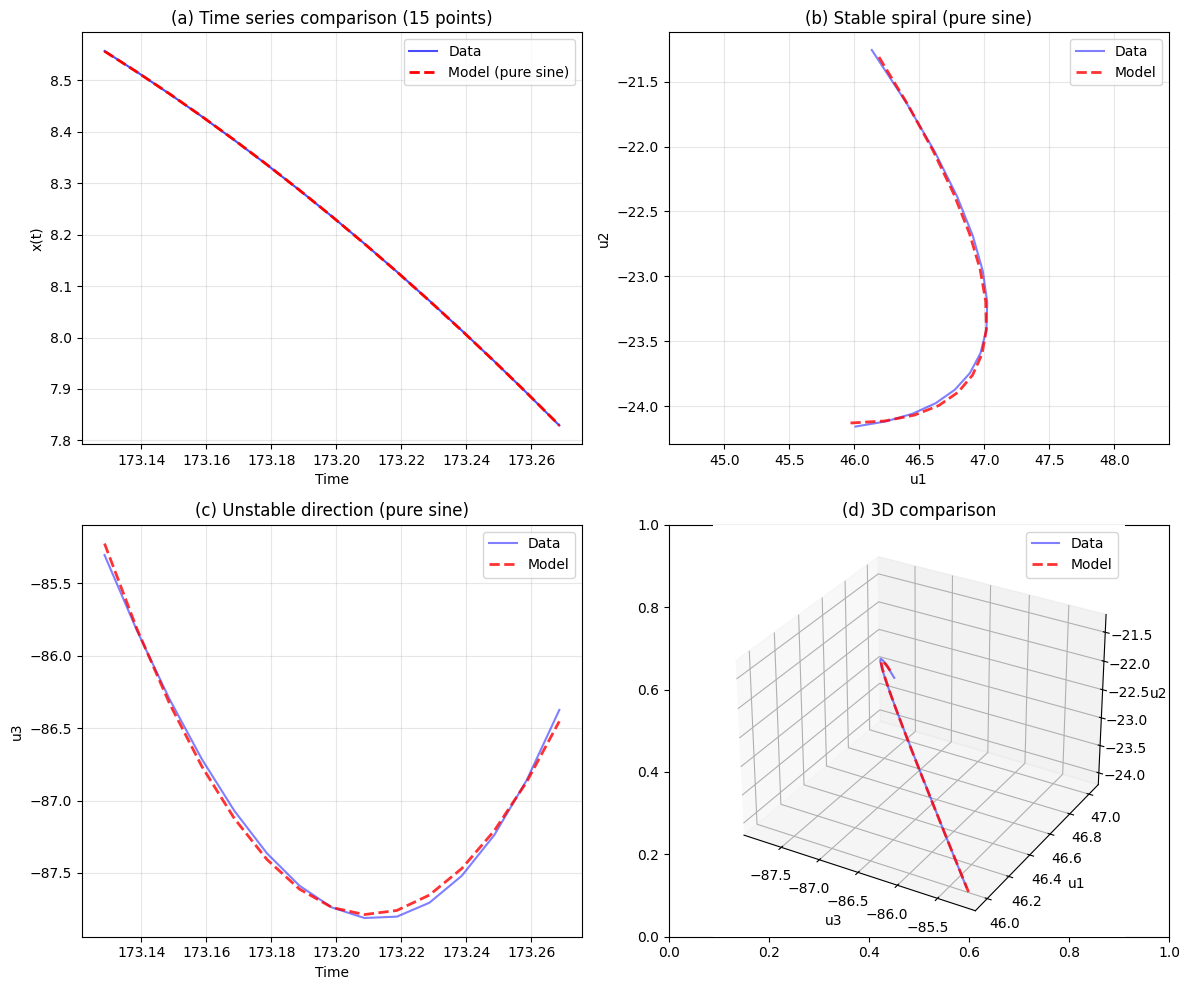

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
from scipy.linalg import lstsq

# ================================================================
# 1. LOAD DATA
# ================================================================
df_eigen = pd.read_csv('eigen_coords.csv')
df_main = pd.read_csv('original_vs_fit.csv')

time = df_eigen['time'].values
u_real_data = df_eigen['u_real_data'].values
u1_data = df_eigen['u1_data'].values
u2_data = df_eigen['u2_data'].values

omega_val = 1.9502957119  # rotation frequency

# ================================================================
# 2. SELECT LOCAL SEGMENT (15 points)
# ================================================================
center_idx = 14
half_window = 7
start = max(0, center_idx - half_window)
end = min(len(time), center_idx + half_window + 1)

t_local = time[start:end]
u3_local = u_real_data[start:end]
u1_local = u1_data[start:end]
u2_local = u2_data[start:end]

t_scaled = t_local - t_local[0]

# ================================================================
# 3. MODEL: PURE SINE (NO EXPONENTIAL)
# ================================================================
def pure_sine(t, A, phi, C):
    return A * np.sin(omega_val * t + phi) + C

# Fit u1
popt1, _ = curve_fit(pure_sine, t_scaled, u1_local, p0=[np.std(u1_local), 0.0, np.mean(u1_local)])
A1, phi1, C1 = popt1
u1_fit = pure_sine(t_scaled, A1, phi1, C1)

# Fit u2
popt2, _ = curve_fit(pure_sine, t_scaled, u2_local, p0=[np.std(u2_local), 0.0, np.mean(u2_local)])
A2, phi2, C2 = popt2
u2_fit = pure_sine(t_scaled, A2, phi2, C2)

# Fit u3
popt3, _ = curve_fit(pure_sine, t_scaled, u3_local, p0=[np.std(u3_local), 0.0, np.mean(u3_local)])
A3, phi3, C3 = popt3
u3_fit = pure_sine(t_scaled, A3, phi3, C3)

# ================================================================
# 4. RECONSTRUCT x(t) AS LINEAR COMBINATION OF u1_fit, u2_fit, u3_fit
# ================================================================
x_orig_local = df_main['x_original'].values[start:end]

A_reg = np.column_stack([u1_fit, u2_fit, u3_fit, np.ones_like(u1_fit)])
coeffs_x, _, _, _ = lstsq(A_reg, x_orig_local)
a1, a2, a3, b = coeffs_x
x_fit = a1 * u1_fit + a2 * u2_fit + a3 * u3_fit + b

# ================================================================
# 5. OUTPUT
# ================================================================
mse = mean_squared_error(x_orig_local, x_fit)

print(f"Model: pure sine (no exponential), 15 points")
print(f"   MSE = {mse:.6f}")
print(f"\nParameters for u1: A={A1:.4f}, phi={phi1:.4f}, C={C1:.4f}")
print(f"Parameters for u2: A={A2:.4f}, phi={phi2:.4f}, C={C2:.4f}")
print(f"Parameters for u3: A={A3:.4f}, phi={phi3:.4f}, C={C3:.4f}")
print(f"Reconstruction coefficients for x: a1={a1:.4f}, a2={a2:.4f}, a3={a3:.4f}, b={b:.4f}")

# ================================================================
# 6. VISUALISATION (Figure 4 with panels (a)–(d))
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Time series
axes[0,0].plot(t_local, x_orig_local, 'b-', label='Data', alpha=0.7)
axes[0,0].plot(t_local, x_fit, 'r--', label='Model (pure sine)', linewidth=2)
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('x(t)')
axes[0,0].set_title('(a) Time series comparison (15 points)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# (b) Stable spiral
axes[0,1].plot(u1_local, u2_local, 'b-', alpha=0.5, label='Data')
axes[0,1].plot(u1_fit, u2_fit, 'r--', alpha=0.8, label='Model', linewidth=2)
axes[0,1].set_xlabel('u1')
axes[0,1].set_ylabel('u2')
axes[0,1].set_title('(b) Stable spiral (pure sine)')
axes[0,1].axis('equal')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# (c) Unstable direction
axes[1,0].plot(t_local, u3_local, 'b-', alpha=0.5, label='Data')
axes[1,0].plot(t_local, u3_fit, 'r--', alpha=0.8, label='Model', linewidth=2)
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('u3')
axes[1,0].set_title('(c) Unstable direction (pure sine)')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# (d) 3D comparison
ax = fig.add_subplot(2, 2, 4, projection='3d')
ax.plot(u3_local, u1_local, u2_local, 'b-', alpha=0.5, label='Data')
ax.plot(u3_fit, u1_fit, u2_fit, 'r--', alpha=0.8, label='Model', linewidth=2)
ax.set_xlabel('u3')
ax.set_ylabel('u1')
ax.set_zlabel('u2')
ax.set_title('(d) 3D comparison')
ax.legend()

plt.tight_layout()
plt.savefig('real_data.png', dpi=300, bbox_inches='tight')
plt.show()